In [4]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='ee-jutharatview')

In [5]:
admin2 = ee.FeatureCollection("FAO/GAUL/2015/level2")

thoen = admin2.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Thailand'),
        ee.Filter.eq('ADM1_NAME', 'Lampang'),
        ee.Filter.eq('ADM2_NAME', 'Thoen')
    )
)

Map = geemap.Map()
Map.centerObject(thoen, 9)
Map.addLayer(thoen, {}, 'Thoen')
Map

Map(center=[17.562920498597165, 99.29227425560849], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
def maskS2clouds(image):
    scl = image.select('SCL')
    mask = (scl.neq(3)
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    return image.updateMask(mask).divide(10000)

In [7]:
def getComposite(start, end):
    return (ee.ImageCollection("COPERNICUS/S2_SR")
            .filterBounds(thoen)
            .filterDate(start, end)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .select(['B2','B3','B4','B8','SCL'])
            .map(maskS2clouds)
            .median()
            .clip(thoen))

img2020 = getComposite('2020-02-01', '2020-04-30')
img2024 = getComposite('2024-02-01', '2024-04-30')

In [8]:
def addIndices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
    return image.addBands([ndvi, ndwi])

img2020 = addIndices(img2020)
img2024 = addIndices(img2024)

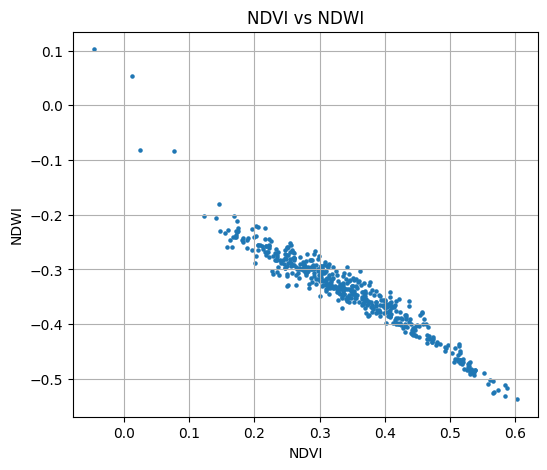

Generating URL ...
An error occurred while downloading.
Total request size (180542295 bytes) must be less than or equal to 50331648 bytes.


In [10]:
# =========================
# 0) Install + Setup
# =========================
!pip install earthengine-api geemap

import ee
import geemap
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='ee-jutharatview')

# =========================
# 1) Study Area
# =========================
admin2 = ee.FeatureCollection("FAO/GAUL/2015/level2")

thoen = admin2.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Thailand'),
        ee.Filter.eq('ADM1_NAME', 'Lampang'),
        ee.Filter.eq('ADM2_NAME', 'Thoen')
    )
)

Map = geemap.Map()
Map.centerObject(thoen, 9)
Map.addLayer(thoen, {}, 'Thoen Boundary')

# =========================
# 2) Cloud Mask
# =========================
def maskS2(image):
    scl = image.select('SCL')
    mask = (scl.neq(3)
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    return image.updateMask(mask).divide(10000)

# =========================
# 3) Composite
# =========================
def getComposite(start, end):
    return (ee.ImageCollection("COPERNICUS/S2_SR")
            .filterBounds(thoen)
            .filterDate(start, end)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .select(['B2','B3','B4','B8','SCL'])
            .map(maskS2)
            .median()
            .clip(thoen))

img2020 = getComposite('2020-02-01', '2020-04-30')
img2024 = getComposite('2024-02-01', '2024-04-30')

# =========================
# 4) NDVI + NDWI
# =========================
def addIndices(image):
    ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')
    ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')
    return image.addBands([ndvi, ndwi])

img2020 = addIndices(img2020)
img2024 = addIndices(img2024)

# =========================
# 5) Change
# =========================
ndviDiff = img2024.select('NDVI').subtract(img2020.select('NDVI'))

# =========================
# 6) Visualization
# =========================
ndviVis = {'min': -1, 'max': 1, 'palette': ['brown','yellow','green']}
ndwiVis = {'min': -1, 'max': 1, 'palette': ['white','blue']}
diffVis = {'min': -0.5, 'max': 0.5, 'palette': ['red','white','green']}

Map.addLayer(img2020.select('NDVI'), ndviVis, 'NDVI 2020')
Map.addLayer(img2024.select('NDVI'), ndviVis, 'NDVI 2024')

Map.addLayer(img2020.select('NDWI'), ndwiVis, 'NDWI 2020')
Map.addLayer(img2024.select('NDWI'), ndwiVis, 'NDWI 2024')

Map.addLayer(ndviDiff, diffVis, 'NDVI Change')

Map   # ⭐ แสดง map

# =========================
# 7) Scatter Plot
# =========================
sample = img2024.select(['NDVI','NDWI']).sample(
    region=thoen,
    scale=10,
    numPixels=500
)

df = geemap.ee_to_df(sample)

plt.figure(figsize=(6,5))
plt.scatter(df['NDVI'], df['NDWI'], s=5)
plt.xlabel('NDVI')
plt.ylabel('NDWI')
plt.title('NDVI vs NDWI')
plt.grid()
plt.show()

# =========================
# 8) Export (GeoTIFF)
# =========================
geemap.ee_export_image(
    img2024.select('NDVI'),
    filename='ndvi_2024.tif',
    scale=30, # Increased scale to reduce file size
    region=thoen.geometry(),
    file_per_band=False
)

In [11]:
Map1 = geemap.Map()
Map1.centerObject(thoen, 9)

Map1.addLayer(img2020.select('NDVI'), ndviVis, 'NDVI 2020')
Map1.addLayer(thoen, {}, 'Boundary')

Map1

Map(center=[17.562920498597165, 99.29227425560849], controls=(WidgetControl(options=['position', 'transparent_…

In [12]:
Map2 = geemap.Map()
Map2.centerObject(thoen, 9)

Map2.addLayer(img2024.select('NDVI'), ndviVis, 'NDVI 2024')
Map2.addLayer(thoen, {}, 'Boundary')

Map2

Map(center=[17.562920498597215, 99.29227425560848], controls=(WidgetControl(options=['position', 'transparent_…

In [13]:
Map3 = geemap.Map()
Map3.centerObject(thoen, 9)

Map3.addLayer(img2020.select('NDWI'), ndwiVis, 'NDWI 2020')
Map3.addLayer(thoen, {}, 'Boundary')

Map3

Map(center=[17.562920498597165, 99.29227425560849], controls=(WidgetControl(options=['position', 'transparent_…

In [14]:
Map4 = geemap.Map()
Map4.centerObject(thoen, 9)

Map4.addLayer(img2024.select('NDWI'), ndwiVis, 'NDWI 2024')
Map4.addLayer(thoen, {}, 'Boundary')

Map4

Map(center=[17.562920498597165, 99.29227425560849], controls=(WidgetControl(options=['position', 'transparent_…

In [15]:
Map5 = geemap.Map()
Map5.centerObject(thoen, 9)

Map5.addLayer(ndviDiff, diffVis, 'NDVI Change')
Map5.addLayer(thoen, {}, 'Boundary')

Map5

Map(center=[17.562920498597215, 99.29227425560848], controls=(WidgetControl(options=['position', 'transparent_…